In [1]:
import pandas as pd

df = pd.read_parquet(r"C:\Users\z3553082\OneDrive - UNSW\Documents\CICCADA - Data\Ausgrid\ausgrid_pv_combined.parquet")

In [2]:
df

,serial,MeasureTime,Vphase,Volts,Curr,ReactPow,ActivePow,month,source_file
0,810813941,2025-04-02 09:40:00,C,240.051147,1.719485,-193.997528,265.470276,2025-04,jm_unswnmisapr25
1,810813941,2025-04-02 09:40:00,B,233.825958,0.411921,-86.788360,35.736385,2025-04,jm_unswnmisapr25
2,810813941,2025-04-02 09:40:00,A,235.732666,2.649141,-112.314354,607.518555,2025-04,jm_unswnmisapr25
3,810813941,2025-04-02 09:45:00,C,239.834700,1.761055,-193.997528,270.575500,2025-04,jm_unswnmisapr25
4,810813941,2025-04-02 09:45:00,A,234.557724,2.399721,-91.893560,551.361400,2025-04,jm_unswnmisapr25
...,...,...,...,...,...,...,...,...,...
303647628,811513156,2024-09-30 23:45:00,A,242.277374,10.687262,342.048248,-2557.704000,2024-09,jm_unswnmissep24
303647629,811513156,2024-09-30 23:50:00,B,240.514938,0.000000,0.000000,0.000000,2024-09,jm_unswnmissep24
303647630,811513156,2024-09-30 23:50:00,A,240.514938,10.849764,-76.577970,-2588.335450,2024-09,jm_unswnmissep24
303647631,811513156,2024-09-30 23:55:00,A,240.112976,11.522441,51.051980,-2751.701660,2024-09,jm_unswnmissep24


In [50]:
SERIAL = 810584444
# SERIAL = 811513156

In [51]:
df_filtered = df[df['serial']==SERIAL].groupby(['serial', 'MeasureTime']).agg({
    'Volts': 'mean',
    'ReactPow': 'sum',
    'ActivePow': 'sum',
    'Curr': 'sum'
}).reset_index()

df_filtered

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr
0,810584444,2024-08-01 00:00:00,243.280548,2031.868780,-2869.121117,16.888747
1,810584444,2024-08-01 00:05:00,244.342124,1669.399720,-2098.236282,13.566928
2,810584444,2024-08-01 00:10:00,243.730601,1322.246282,234.839098,11.363719
3,810584444,2024-08-01 00:15:00,244.386785,1730.662070,178.681965,13.090763
4,810584444,2024-08-01 00:20:00,244.503596,1771.503720,755.569300,10.853543
...,...,...,...,...,...,...
105115,810584444,2025-07-31 23:35:00,237.261490,-464.573017,102.103958,2.826758
105116,810584444,2025-07-31 23:40:00,236.876709,-454.362613,944.461622,5.729098
105117,810584444,2025-07-31 23:45:00,237.278663,-454.362623,265.470299,2.815421
105118,810584444,2025-07-31 23:50:00,237.907367,-81.683170,1393.719049,6.605847


In [52]:
df_filtered['ApparentPow'] = ((df_filtered['ReactPow'] ** 2) + (df_filtered['ActivePow'] ** 2)) ** 0.5
df_filtered

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr,ApparentPow
0,810584444,2024-08-01 00:00:00,243.280548,2031.868780,-2869.121117,16.888747,3515.728477
1,810584444,2024-08-01 00:05:00,244.342124,1669.399720,-2098.236282,13.566928,2681.322607
2,810584444,2024-08-01 00:10:00,243.730601,1322.246282,234.839098,11.363719,1342.938804
3,810584444,2024-08-01 00:15:00,244.386785,1730.662070,178.681965,13.090763,1739.861617
4,810584444,2024-08-01 00:20:00,244.503596,1771.503720,755.569300,10.853543,1925.905085
...,...,...,...,...,...,...,...
105115,810584444,2025-07-31 23:35:00,237.261490,-464.573017,102.103958,2.826758,475.660915
105116,810584444,2025-07-31 23:40:00,236.876709,-454.362613,944.461622,5.729098,1048.071152
105117,810584444,2025-07-31 23:45:00,237.278663,-454.362623,265.470299,2.815421,526.231767
105118,810584444,2025-07-31 23:50:00,237.907367,-81.683170,1393.719049,6.605847,1396.110643


In [53]:
# Choose a random 7-day window from the full-year data using MeasureTime
possible_starts = pd.date_range(
    start=df_filtered['MeasureTime'].min().normalize(),
    end=df_filtered['MeasureTime'].max().normalize() - pd.Timedelta(days=7),
    freq='D'
)

random_start = possible_starts.to_series().sample(1).iloc[0]

df_random_week = df_filtered[
    (df_filtered['MeasureTime'] >= random_start) &
    (df_filtered['MeasureTime'] < random_start + pd.Timedelta(days=7))
].copy()

df_random_week

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr,ApparentPow
46656,810584444,2025-01-10 00:00:00,241.573079,643.254930,245.049528,14.024197,688.350330
46657,810584444,2025-01-10 00:05:00,241.820441,811.726453,377.784736,14.564608,895.332977
46658,810584444,2025-01-10 00:10:00,241.617747,587.097745,-127.629912,13.873035,600.810417
46659,810584444,2025-01-10 00:15:00,241.978480,913.830422,-61.262352,14.587282,915.881605
46660,810584444,2025-01-10 00:20:00,242.363254,888.304426,-786.200462,14.632631,1186.252890
...,...,...,...,...,...,...,...
48667,810584444,2025-01-16 23:35:00,242.071233,648.360160,1383.508611,12.943379,1527.896257
48668,810584444,2025-01-16 23:40:00,241.349772,663.675707,2016.553073,13.510242,2122.958252
48669,810584444,2025-01-16 23:45:00,241.885714,1010.829143,1010.829144,14.352979,1429.528284
48670,810584444,2025-01-16 23:50:00,242.136509,643.254920,1740.872338,13.865476,1855.913088


<Axes: title={'center': 'Power over Time for Serial 810584444 (Random Week Starting 2025-01-10)'}, xlabel='MeasureTime'>

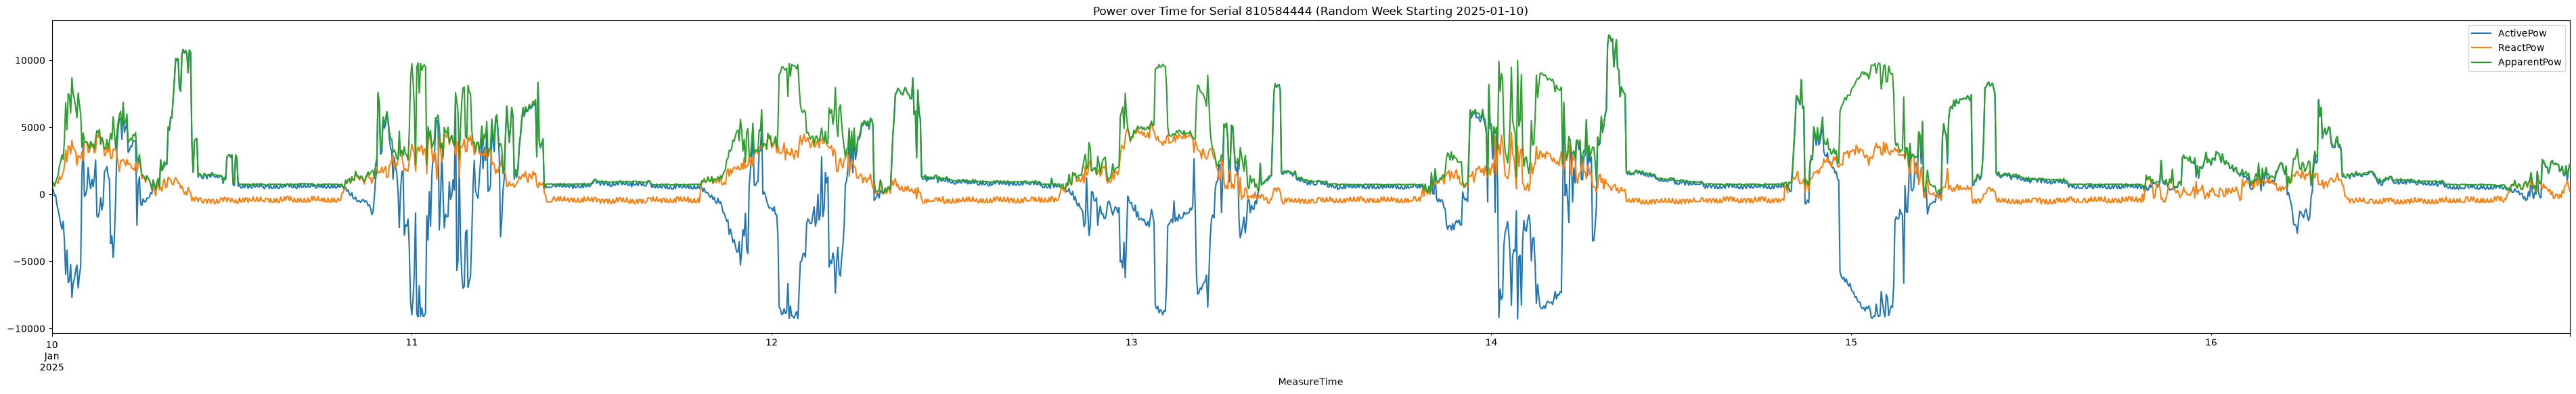

In [54]:
df_random_week.plot(x='MeasureTime', y=['ActivePow', 'ReactPow', 'ApparentPow'], figsize=(48, 6), kind='line', title=f'Power over Time for Serial 810584444 (Random Week Starting {random_start.date()})')

In [55]:
middle_day = random_start + pd.Timedelta(days=3)  # 4th day of the 7-day window

df_middle_day = df_random_week[
    (df_random_week['MeasureTime'] >= middle_day) &
    (df_random_week['MeasureTime'] < middle_day + pd.Timedelta(days=1))
].copy()

df_middle_day

,serial,MeasureTime,Volts,ReactPow,ActivePow,Curr,ApparentPow
47520,810584444,2025-01-13 00:00:00,245.362478,4252.629944,-622.834227,35.160640,4297.997663
47521,810584444,2025-01-13 00:05:00,245.190699,4196.472555,-1051.670730,35.232443,4326.244703
47522,810584444,2025-01-13 00:10:00,245.259410,4609.993900,-1250.773558,37.125766,4776.659738
47523,810584444,2025-01-13 00:15:00,245.475849,4538.521044,-801.515937,37.707747,4608.752658
47524,810584444,2025-01-13 00:20:00,245.578916,4558.941724,-1705.136030,37.945829,4867.385183
...,...,...,...,...,...,...,...
47803,810584444,2025-01-13 23:35:00,241.696762,2108.446768,5171.565376,33.683017,5584.857761
47804,810584444,2025-01-13 23:40:00,240.813828,1557.085348,4523.205560,31.211493,4783.712295
47805,810584444,2025-01-13 23:45:00,241.607442,1301.825516,-561.571720,19.878006,1417.784352
47806,810584444,2025-01-13 23:50:00,242.569392,1950.185565,7948.793217,40.515609,8184.530368


<Axes: title={'center': 'Power over Time for Serial 810584444 (Middle Day: 2025-01-13)'}, xlabel='MeasureTime'>

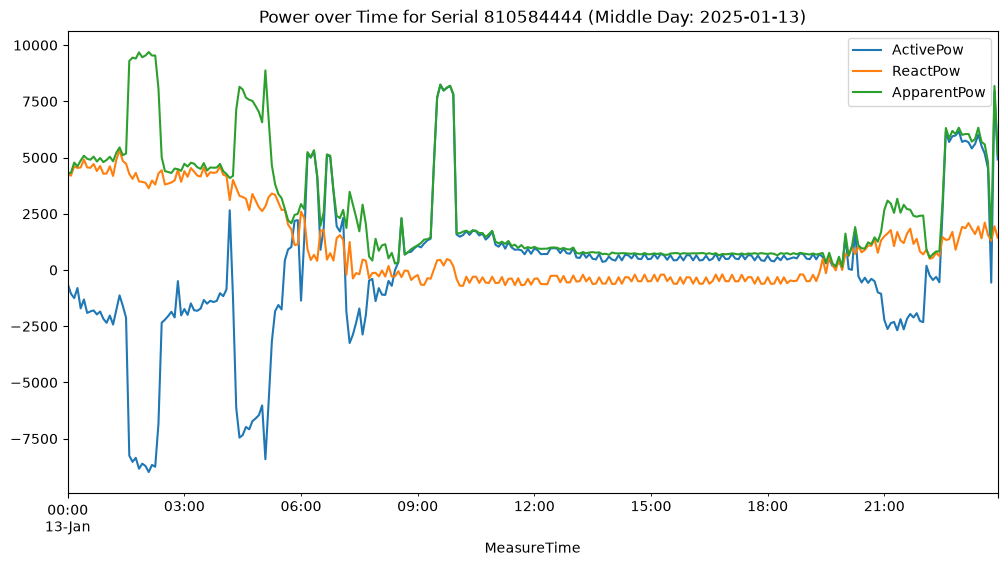

In [56]:
df_middle_day.plot(x='MeasureTime', y=['ActivePow', 'ReactPow', 'ApparentPow'], figsize=(12, 6), kind='line', title=f'Power over Time for Serial 810584444 (Middle Day: {middle_day.date()})')

In [57]:
df_middle_day_full = df[
    (df['MeasureTime'] >= middle_day) &
    (df['MeasureTime'] < middle_day + pd.Timedelta(days=1))
].copy()

df_middle_day_full

,serial,MeasureTime,Vphase,Volts,Curr,ReactPow,ActivePow,month,source_file
94215969,326214487,2025-01-13 00:00:00,B,243.988266,0.967447,-178.681931,86.788360,2025-01,jm_unswnmisjan25
94215970,326214487,2025-01-13 00:00:00,A,244.379913,0.604654,-71.472770,112.314354,2025-01,jm_unswnmisjan25
94215971,326214487,2025-01-13 00:00:00,C,246.997787,19.700390,1163.985110,-4717.202640,2025-01,jm_unswnmisjan25
94215972,326214487,2025-01-13 00:05:00,C,246.832886,19.692831,1153.774780,-4712.097660,2025-01,jm_unswnmisjan25
94215973,326214487,2025-01-13 00:05:00,B,244.029500,0.963668,-173.576721,86.788360,2025-01,jm_unswnmisjan25
...,...,...,...,...,...,...,...,...,...
119942789,811513156,2025-01-13 23:45:00,B,234.598953,0.000000,0.000000,0.000000,2025-01,jm_unswnmisjan25
119942790,811513156,2025-01-13 23:50:00,B,235.237961,0.000000,0.000000,0.000000,2025-01,jm_unswnmisjan25
119942791,811513156,2025-01-13 23:50:00,A,235.237961,11.779419,30.631187,-2761.912000,2025-01,jm_unswnmisjan25
119942792,811513156,2025-01-13 23:55:00,A,233.588900,6.171252,214.418300,-1352.877440,2025-01,jm_unswnmisjan25


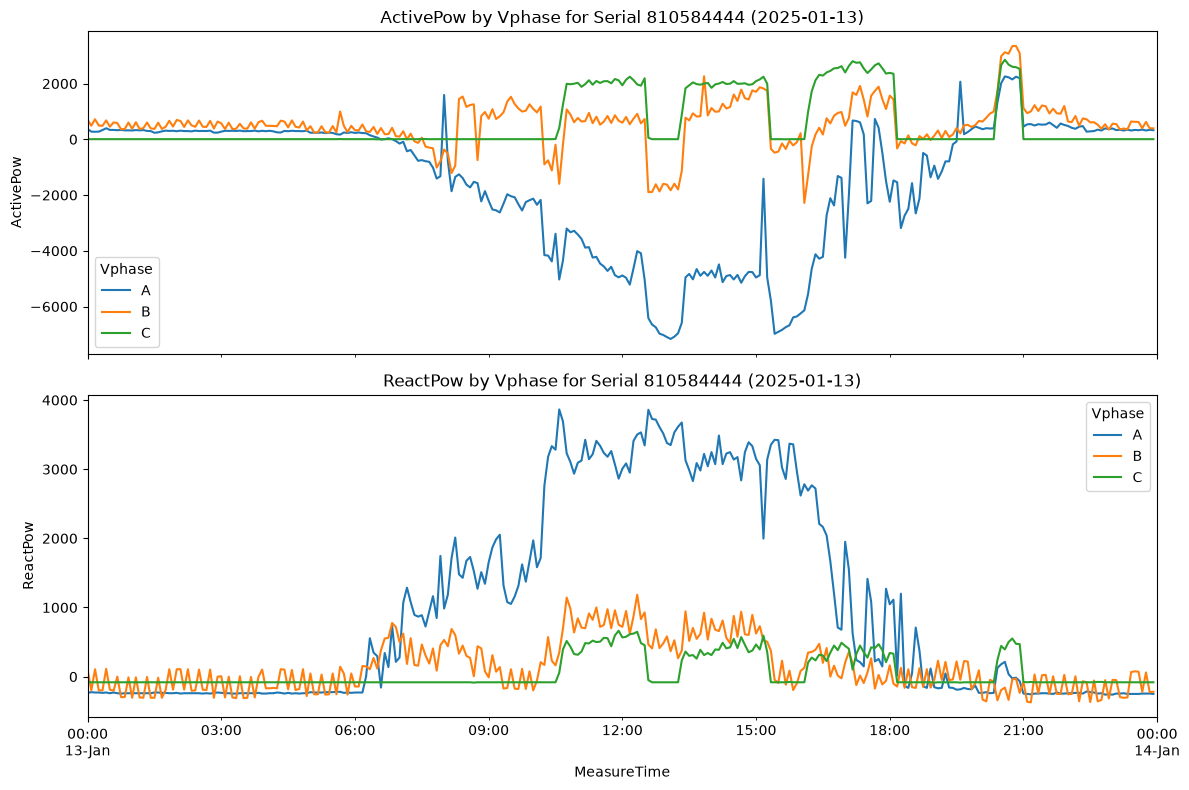

In [58]:
import matplotlib.pyplot as plt

# Convert to Australia/Sydney time and filter to one local day (00:00 -> midnight)
df_oneserial = df.copy()
df_oneserial['MeasureTime'] = pd.to_datetime(df_oneserial['MeasureTime'], utc=True).dt.tz_convert('Australia/Sydney')

day_start = pd.Timestamp(middle_day.date(), tz='Australia/Sydney')
day_end = day_start + pd.Timedelta(days=1)

df_oneserial = df_oneserial[
    (df_oneserial['serial'] == 810584444) &
    (df_oneserial['MeasureTime'] >= day_start) &
    (df_oneserial['MeasureTime'] < day_end)
].copy()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for ax, metric in zip(axes, ['ActivePow', 'ReactPow']):
    (
        df_oneserial
        .pivot_table(index='MeasureTime', columns='Vphase', values=metric, aggfunc='mean')
        .sort_index()
        .plot(ax=ax)
    )
    ax.set_title(f'{metric} by Vphase for Serial 810584444 ({day_start.date()})')
    ax.set_ylabel(metric)
    ax.set_xlim(day_start, day_end)

plt.tight_layout()

In [59]:
df_oneserial['ApparentPow'] = ((df_oneserial['ReactPow'] ** 2) + (df_oneserial['ActivePow'] ** 2)) ** 0.5
df_oneserial

,serial,MeasureTime,Vphase,Volts,Curr,ReactPow,ActivePow,month,source_file,ApparentPow
99075093,810584444,2025-01-13 00:00:00+11:00,B,242.875153,3.049725,96.998764,699.412100,2025-01,jm_unswnmisjan25,706.106257
99075094,810584444,2025-01-13 00:00:00+11:00,A,242.349518,2.002917,-234.839111,367.574249,2025-01,jm_unswnmisjan25,436.188304
99075095,810584444,2025-01-13 00:00:00+11:00,C,243.132813,0.336339,-81.683170,5.105198,2025-01,jm_unswnmisjan25,81.842552
99075096,810584444,2025-01-13 00:05:00+11:00,C,241.978470,0.336339,-81.683170,5.105198,2025-01,jm_unswnmisjan25,81.842552
99075097,810584444,2025-01-13 00:05:00+11:00,B,242.761780,2.407279,-199.102722,490.099000,2025-01,jm_unswnmisjan25,528.998038
...,...,...,...,...,...,...,...,...,...,...
99075952,810584444,2025-01-13 23:50:00+11:00,A,244.297455,1.847974,-245.049500,342.048248,2025-01,jm_unswnmisjan25,420.768655
99075953,810584444,2025-01-13 23:50:00+11:00,C,243.194656,0.343897,-81.683170,5.105198,2025-01,jm_unswnmisjan25,81.842552
99075954,810584444,2025-01-13 23:55:00+11:00,B,242.431961,1.980242,-219.523514,393.100250,2025-01,jm_unswnmisjan25,450.242579
99075955,810584444,2025-01-13 23:55:00+11:00,A,244.534515,1.802625,-250.154700,326.732666,2025-01,jm_unswnmisjan25,411.499221


In [61]:
df_oneserial

,serial,MeasureTime,Vphase,Volts,Curr,ReactPow,ActivePow,month,source_file
16983257,810584444,2025-04-06 00:00:00+11:00,B,244.586044,2.052045,-377.784637,285.891083,2025-04,jm_unswnmisapr25
16983258,810584444,2025-04-06 00:00:00+11:00,C,244.864319,0.343897,-81.683170,5.105198,2025-04,jm_unswnmisapr25
16983259,810584444,2025-04-06 00:00:00+11:00,A,243.101900,1.564543,-239.944300,275.680700,2025-04,jm_unswnmisapr25
16983260,810584444,2025-04-06 00:05:00+11:00,A,242.112457,1.700590,-239.944300,301.206665,2025-04,jm_unswnmisapr25
16983261,810584444,2025-04-06 00:05:00+11:00,C,243.916122,0.340118,-81.683170,5.105198,2025-04,jm_unswnmisapr25
...,...,...,...,...,...,...,...,...,...
16984116,810584444,2025-04-06 22:50:00+10:00,B,241.875412,1.609892,-321.627472,153.155945,2025-04,jm_unswnmisapr25
16984117,810584444,2025-04-06 22:50:00+10:00,C,245.018921,0.343897,-81.683170,5.105198,2025-04,jm_unswnmisapr25
16984118,810584444,2025-04-06 22:55:00+10:00,C,245.688858,0.343897,-81.683170,5.105198,2025-04,jm_unswnmisapr25
16984119,810584444,2025-04-06 22:55:00+10:00,B,240.741684,1.659020,-30.631187,372.679443,2025-04,jm_unswnmisapr25


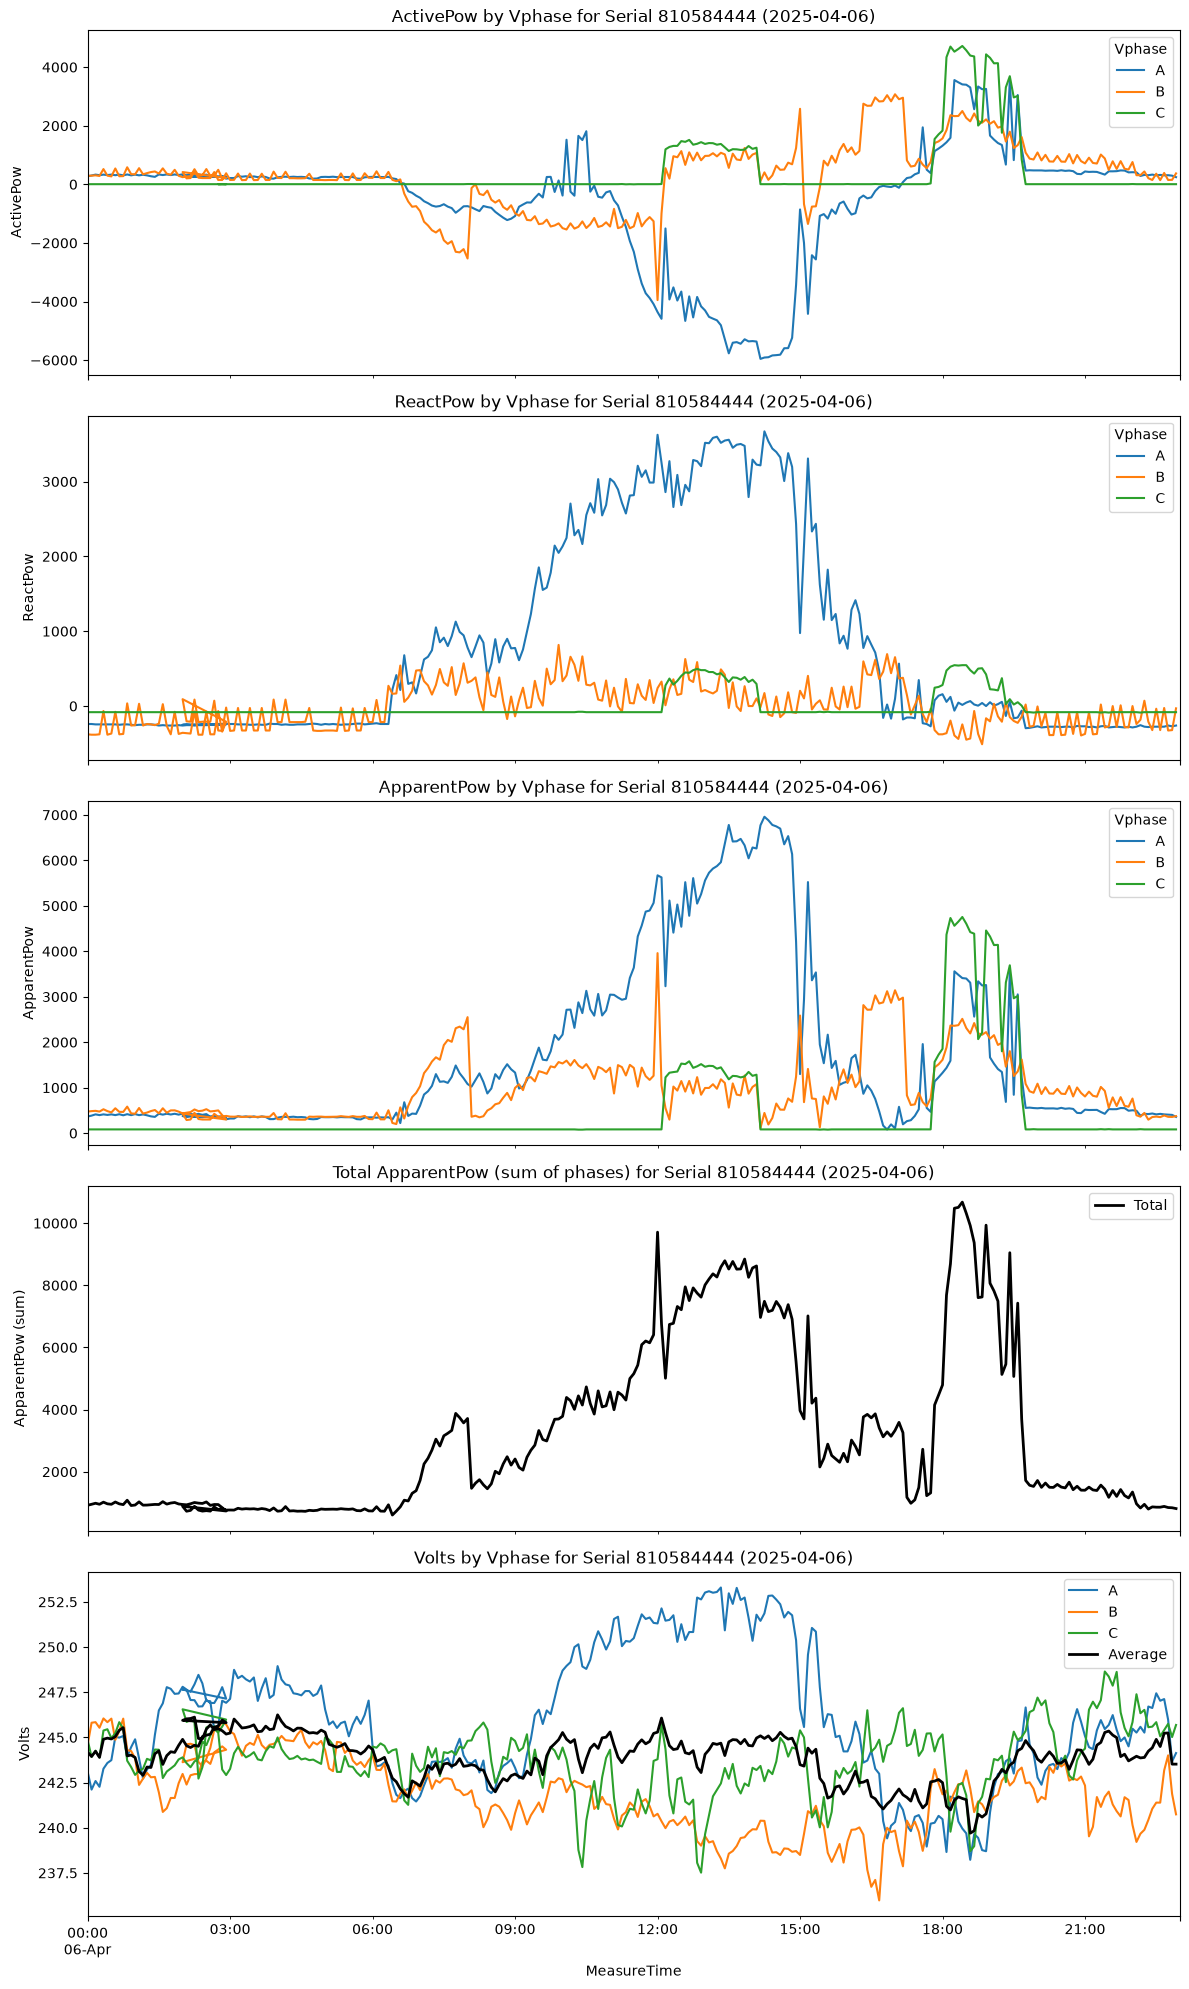

In [62]:
day_start = pd.Timestamp('2025-04-06', tz='Australia/Sydney')  # 06-04-2025 = 6 Apr 2025
day_end = day_start + pd.Timedelta(days=1)

df_oneserial = df.copy()
df_oneserial['MeasureTime'] = pd.to_datetime(df_oneserial['MeasureTime'], utc=True).dt.tz_convert('Australia/Sydney')
df_oneserial['ApparentPow'] = ((df_oneserial['ReactPow'] ** 2) + (df_oneserial['ActivePow'] ** 2)) ** 0.5

df_oneserial = df_oneserial[
    (df_oneserial['serial'] == SERIAL) &
    (df_oneserial['MeasureTime'] >= day_start) &
    (df_oneserial['MeasureTime'] < day_end)
].copy()

fig, axes = plt.subplots(5, 1, figsize=(12, 20), sharex=True)

phases = sorted(df_oneserial['Vphase'].unique())
palette = plt.cm.tab10.colors
phase_colors = {phase: palette[i] for i, phase in enumerate(phases)}

power_metrics = ['ActivePow', 'ReactPow', 'ApparentPow']

for ax, metric in zip(axes[:3], power_metrics):
    pivoted = (
        df_oneserial
        .pivot_table(index='MeasureTime', columns='Vphase', values=metric, aggfunc='mean')
        .sort_index()
    )
    pivoted.plot(ax=ax, color=[phase_colors[c] for c in pivoted.columns])
    ax.set_title(f'{metric} by Vphase for Serial {SERIAL} ({day_start.date()})')
    ax.set_ylabel(metric)
    ax.set_xlim(day_start, day_end)

total_apparent = (
    df_oneserial
    .pivot_table(index='MeasureTime', columns='Vphase', values='ApparentPow', aggfunc='mean')
    .sort_index()
    .sum(axis=1)
)
total_apparent.plot(ax=axes[3], color='black', linewidth=2, label='Total')
axes[3].set_title(f'Total ApparentPow (sum of phases) for Serial {SERIAL} ({day_start.date()})')
axes[3].set_ylabel('ApparentPow (sum)')
axes[3].set_xlim(day_start, day_end)
axes[3].legend()

pivoted_volts = (
    df_oneserial
    .pivot_table(index='MeasureTime', columns='Vphase', values='Volts', aggfunc='mean')
    .sort_index()
)
pivoted_volts.plot(ax=axes[4], color=[phase_colors[c] for c in pivoted_volts.columns])
pivoted_volts.mean(axis=1).plot(ax=axes[4], color='black', linewidth=2, label='Average')
axes[4].set_title(f'Volts by Vphase for Serial {SERIAL} ({day_start.date()})')
axes[4].set_ylabel('Volts')
axes[4].set_xlim(day_start, day_end)
axes[4].legend()

plt.tight_layout()